# Kuhn Poker: CFR e ISMCTS

Kuhn Poker es un juego de **suma cero**, **2 jugadores** e **información imperfecta** (cada jugador sólo conoce su propia carta):

- **Baraja:** J (0), Q (1), K (2). Cada jugador recibe 1 carta.
- **Acciones:** `p` = pasar (0), `b` = apostar (1).
- **Turno:** agente_0 actúa primero; agente_1 segundo. Si agente_0 pasó y agente_1 apuesta, agente_0 actúa una vez más.
- **Observación:** carta propia + historial público. Ejemplo: agente_0 tiene Q, historial `pb` → observación `'1pb'`.
- **Recompensas:** `pp`/`bp` → ±1 por carta más alta; `pbp` → ±1 para agente_1; `pbb`/`bb` → ±2 por carta más alta.

## Equilibrio de Nash

 En Kuhn Poker, como el juego es finito y de suma cero, este equilibrio existe y está esencialmente determinado (salvo un parámetro libre α).

### Information sets

Cada jugador sólo conoce su propia carta. Un **information set** agrupa todos los estados del juego que un agente no puede distinguir entre sí. Por ejemplo, cuando agente_1 ve el historial `p` (agente_0 pasó), no sabe si agente_0 tiene J, Q o K — esa incertidumbre define su information set. En estrategia óptima, las decisiones se toman por information set, no por estado individual.

Agente_0 tiene 6 information sets:
- `{0, 1, 2}`: primera decisión (sólo conoce su carta, historial vacío)
- `{0pb, 1pb, 2pb}`: segunda decisión (agente_0 pasó, agente_1 apostó)

Agente_1 tiene 6 information sets:
- `{0p, 1p, 2p}`: agente_0 pasó
- `{0b, 1b, 2b}`: agente_0 apostó

### Intuición de las estrategias óptimas

**Agente_0 con K — siempre apuesta:** K es la carta más fuerte. Si va a muestra siempre gana, así que conviene maximizar el bote apostando.

**Agente_0 con Q — siempre pasa:** Si apuesta con Q, agente_1 debería fold con J (pierde) y call con K (pierde) — apostar no tiene valor esperado positivo con una carta media. Pasar fuerza a agente_1 a decidir en la oscuridad.

**Agente_0 con J — apuesta con prob 1/3 (bluff):** J es la carta más débil; sólo puede ganar si el rival hace fold. Apostar con J es un bluff. La probabilidad 1/3 no es arbitraria: es exactamente la que hace que agente_1 con Q sea **indiferente** entre call y pass cuando ve una apuesta. Si agente_0 bluffeara más, agente_1 siempre haría call con Q; si bluffeara menos, agente_1 nunca haría call — en ambos casos agente_0 podría haber elegido mejor.

**Principio de indiferencia:** en un equilibrio de estrategias mixtas, las probabilidades se eligen de modo que el rival quede indiferente entre sus opciones. Es lo que fija los valores 1/3 y 1/9 de la tabla — no son coincidencias sino la solución de un sistema de ecuaciones de indiferencia.

**Agente_1 con Q — call con prob 1/3 tras una apuesta:** Si hace call con más frecuencia, agente_0 dejaría de bluffear con J. Si hace call menos, agente_0 bluffearía siempre. La prob 1/3 deja a agente_0 indiferente entre apostar o pasar con J.

**Agente_1 con K — siempre llama:** K gana la muestra contra cualquier carta, así que nunca conviene fold.

**Agente_1 con J — nunca llama:** J pierde la muestra contra cualquier carta; no hay razón para poner más dinero.

### Valor del juego y la desventaja del primer jugador

El valor del juego en equilibrio es **−1/18 ≈ −0.056** para agente_0. La desventaja del primer jugador surge porque actuar primero revela información: al apostar o pasar, agente_0 da una señal sobre su carta que agente_1 puede explotar. Esta asimetría informacional es la esencia de los juegos de información imperfecta.

### Políticas óptimas (parámetro α = 1/3)

| Agente | Info set | Prob. de apostar/call |
|--------|----------|-----------------------|
| 0 | `0` J inicio | 1/3 |
| 0 | `1` Q inicio | 0 |
| 0 | `2` K inicio | 1 |
| 0 | `0pb` J tras apuesta | 0 |
| 0 | `1pb` Q tras apuesta | 1/9 |
| 0 | `2pb` K tras apuesta | 1 |
| 1 | `0p` J tras paso | 0 |
| 1 | `1p` Q tras paso | 1/3 |
| 1 | `2p` K tras paso | 1 |
| 1 | `0b` J tras apuesta | 0 |
| 1 | `1b` Q tras apuesta | 1/3 |
| 1 | `2b` K tras apuesta | 1 |

## Los algoritmos

- **CFR:** calcula el Nash eq iterativamente minimizando regret contrafactual. Se entrena offline y luego decide en O(1).
- **ISMCTS:** extiende MCTS a info imperfecta samplando cartas posibles del rival en cada simulación. Decide online.

In [152]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

from games.kuhn.kuhn import KuhnPoker
from agents.agent_random import RandomAgent
from agents.counterfactualregret import CounterFactualRegret
from agents.ismcts import InformationSetMCTS

game = KuhnPoker(initial_player=0)  # agent_0 siempre actúa primero
game.reset()

NASH_0 = -1 / 18
NASH_1 = +1 / 18

FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'KuhnPoker')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Guardada: {path}')

PLAIN = FuncFormatter(lambda v, _: f'{v:g}')

def log_xticks(ax, ticks):
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(PLAIN)
    ax.xaxis.set_minor_formatter(NullFormatter())

def kuhn_sample(g, agent):
    return g.random_change(agent)

def train_alternated(c0, c1, total_iters, block=100):
    for _ in range(total_iters // block):
        c0.train(block)
        c1.train(block)
    rem = total_iters % block
    if rem:
        c0.train(rem)
        c1.train(rem)

## Demo: una partida con agentes aleatorios

In [153]:
rnd = {a: RandomAgent(game=game, agent=a) for a in game.agents}

game.reset()
game.render()
while not game.terminated():
    a = rnd[game.agent_selection].action()
    print(f'  {game.agent_selection} → {game.action_move(a)}')
    game.step(a)
game.render()
print('Recompensas:', game.rewards)

agent_0 Q 
agent_1 J 
  agent_0 → b
  agent_1 → p
agent_0 Q bp
agent_1 J bp
Recompensas: {'agent_0': 1, 'agent_1': -1}


## CFR: entrenamiento y comparación con Nash

Se entrenan dos agentes CFR (uno por rol) con 1000 iteraciones \
y se compara cada política aprendida con los valores teóricos.

In [154]:
NASH_BET = {
    'agent_0': {'0': 1/3, '1': 0.0, '2': 1.0, '0pb': 0.0, '1pb': 1/9, '2pb': 1.0},
    'agent_1': {'0p': 0.0, '1p': 1/3, '2p': 1.0, '0b': 0.0, '1b': 1/3, '2b': 1.0},
}

c0 = CounterFactualRegret(game=game, agent='agent_0')
c1 = CounterFactualRegret(game=game, agent='agent_1')
c1.node_dict = c0.node_dict
train_alternated(c0, c1, total_iters=50_000, block=100)

print(f'Nodos aprendidos: {len(c0.node_dict)}')

shared = c0.node_dict
rows = []
for a in game.agents:
    for info_set, nash_val in NASH_BET[a].items():
        cfr_val = shared[info_set].policy()[1] if info_set in shared else float('nan')
        rows.append(dict(agente=a, info_set=info_set,
                         cfr=round(cfr_val, 4), nash=round(nash_val, 4),
                         error=round(abs(cfr_val - nash_val), 4)))
pd.DataFrame(rows)

Nodos aprendidos: 12


,agente,info_set,cfr,nash,error
0,agent_0,0,0.2952,0.3333,0.0382
1,agent_0,1,0.0030,0.0000,0.0030
2,agent_0,2,0.8726,1.0000,0.1274
3,agent_0,0pb,0.0000,0.0000,0.0000
4,agent_0,1pb,0.6416,0.1111,0.5304
5,agent_0,2pb,1.0000,1.0000,0.0000
6,agent_1,0p,0.3272,0.0000,0.3272
7,agent_1,1p,0.0010,0.3333,0.3323
8,agent_1,2p,0.9991,1.0000,0.0009
9,agent_1,0b,0.0000,0.0000,0.0000


Guardada: ../informe/figures/KuhnPoker/cfr_convergencia.png


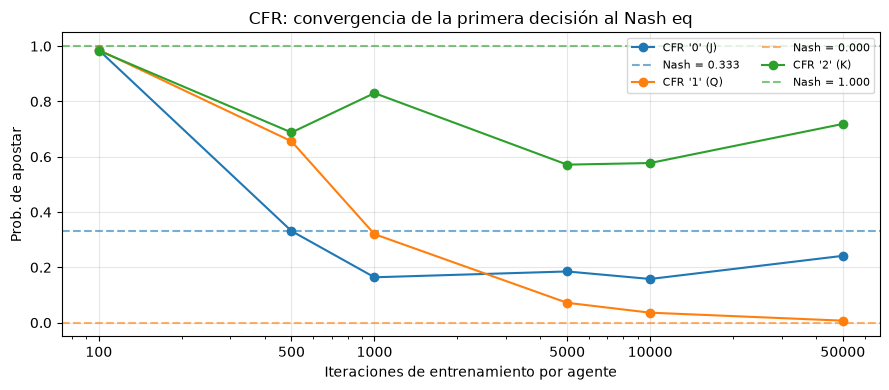

In [155]:
checkpoints = [100, 500, 1000, 5000, 10_000, 50_000]
info_sets_0 = {'0': ('J', 1/3), '1': ('Q', 0.0), '2': ('K', 1.0)}

c0_conv = CounterFactualRegret(game=game, agent='agent_0')
c1_conv = CounterFactualRegret(game=game, agent='agent_1')
c1_conv.node_dict = c0_conv.node_dict

history = {k: [] for k in info_sets_0}
prev = 0
for ck in checkpoints:
    train_alternated(c0_conv, c1_conv, total_iters=ck - prev, block=min(100, ck - prev))
    prev = ck
    for k in info_sets_0:
        val = c0_conv.node_dict[k].policy()[1] if k in c0_conv.node_dict else float('nan')
        history[k].append(val)

fig, ax = plt.subplots(figsize=(9, 4))
for k, (card, nash_val) in info_sets_0.items():
    color = ax.plot(checkpoints, history[k], marker='o', label=f"CFR '{k}' ({card})")[0].get_color()
    ax.axhline(nash_val, linestyle='--', alpha=0.6, color=color,
               label=f"Nash = {nash_val:.3f}")
ax.set_xscale('log')
log_xticks(ax, checkpoints)
ax.set_xlabel('Iteraciones de entrenamiento por agente')
ax.set_ylabel('Prob. de apostar')
ax.set_title('CFR: convergencia de la primera decisión al Nash eq')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'cfr_convergencia.png')
plt.show()

## ISMCTS: demostración

En cada simulación, ISMCTS samplea una carta posible para el rival usando `random_change`, \
luego corre MCTS sobre ese estado determinizado.

In [156]:
ismcts = {
    a: InformationSetMCTS(game=game, agent=a, simulations=100, rollouts=10,
                          sample_from_infoset=kuhn_sample)
    for a in game.agents
}

game.reset()
game.render()
while not game.terminated():
    a = ismcts[game.agent_selection].action()
    print(f'  {game.agent_selection} (obs={game.observe(game.agent_selection)!r}) → {game.action_move(a)}')
    game.step(a)
game.render()
print('Recompensas:', game.rewards)

agent_0 J 
agent_1 K 
  agent_0 (obs='0') → p
  agent_1 (obs='2p') → b
  agent_0 (obs='0pb') → p
agent_0 J pbp
agent_1 K pbp
Recompensas: {'agent_0': -1, 'agent_1': 1}


## Experimento 1 — CFR vs Random: efecto de las iteraciones de entrenamiento

CFR como agente_0 (primer jugador) contra Random, variando `train_iters`.

In [157]:
iter_grid = [100, 500, 1000, 2000]
N = 500

rows = []
all_rewards_exp1 = {}

for iters in iter_grid:
    cfr0 = CounterFactualRegret(game=game, agent='agent_0')
    cfr0.train(iters)

    agents = {'agent_0': cfr0, 'agent_1': RandomAgent(game=game, agent='agent_1')}
    rewards = []
    for _ in range(N):
        game.reset()
        while not game.terminated():
            a = agents[game.agent_selection].action()
            game.step(a)
        rewards.append(game.reward('agent_0'))

    r = np.array(rewards)
    all_rewards_exp1[iters] = r
    rows.append(dict(iters=iters, avg_reward=r.mean(), win_rate=(r > 0).mean()))

df_exp1 = pd.DataFrame(rows)
df_exp1

,iters,avg_reward,win_rate
0,100,0.418,0.728
1,500,0.612,0.776
2,1000,0.576,0.770
3,2000,0.484,0.752


Guardada: ../informe/figures/KuhnPoker/exp1_cfr_vs_random.png


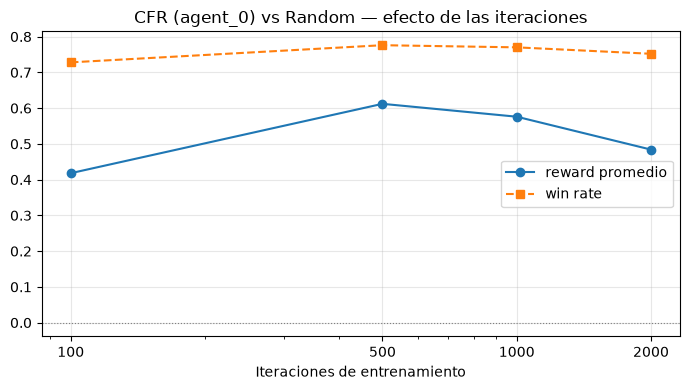

In [158]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_exp1.iters, df_exp1.avg_reward, marker='o', label='reward promedio')
ax.plot(df_exp1.iters, df_exp1.win_rate, marker='s', linestyle='--', label='win rate')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xscale('log')
log_xticks(ax, iter_grid)
ax.set_xlabel('Iteraciones de entrenamiento')
ax.set_title('CFR (agent_0) vs Random — efecto de las iteraciones')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'exp1_cfr_vs_random.png')
plt.show()

In [159]:
# Estadísticas detalladas de rewards — Exp 1
rows_detail = []
for iters, r in all_rewards_exp1.items():
    rows_detail.append(dict(
        iters=iters,
        mean=round(r.mean(), 4),
        std=round(r.std(), 4),
        win_pct=round((r > 0).mean() * 100, 1),
        loss_pct=round((r < 0).mean() * 100, 1),
        p25=round(np.percentile(r, 25), 2),
        p75=round(np.percentile(r, 75), 2),
    ))
pd.DataFrame(rows_detail)

,iters,mean,std,win_pct,loss_pct,p25,p75
0,100,0.418,1.5150,72.8,27.2,-2.0,1.0
1,500,0.612,1.4661,77.6,22.4,1.0,2.0
2,1000,0.576,1.4643,77.0,23.0,1.0,2.0
3,2000,0.484,1.4811,75.2,24.8,1.0,1.0


**Análisis — Exp 1:**
Con pocas iteraciones (100), CFR ya supera ampliamente a Random porque incluso una política \
subóptima domina decisiones aleatorias en un espacio de sólo 12 information sets. \
El reward promedio satura rápidamente: la ganancia marginal entre 1000 y 5000 iteraciones \
es pequeña, lo que indica que CFR converge en pocas iteraciones en Kuhn Poker. \
La desviación estándar refleja la varianza natural del juego (las cartas se reparten al azar) \
y no baja con más entrenamiento — el ruido es del juego, no del agente.

## Experimento 2 — ISMCTS vs Random: efecto del número de simulaciones

ISMCTS como agente_0 contra Random, variando `simulations`.

In [160]:
sim_grid = [5, 10, 25, 50, 100, 200]

rows = []
for sims in sim_grid:
    ism0 = InformationSetMCTS(game=game, agent='agent_0', simulations=sims,
                               rollouts=10, sample_from_infoset=kuhn_sample)
    rnd1 = RandomAgent(game=game, agent='agent_1')
    agents = {'agent_0': ism0, 'agent_1': rnd1}

    rewards, times = [], []
    for _ in range(N):
        game.reset()
        while not game.terminated():
            aid = game.agent_selection
            t0 = time.perf_counter()
            a = agents[aid].action()
            if aid == 'agent_0':
                times.append(time.perf_counter() - t0)
            game.step(a)
        rewards.append(game.reward('agent_0'))

    r = np.array(rewards)
    rows.append(dict(sims=sims, avg_reward=r.mean(), win_rate=(r > 0).mean(),
                     avg_time_ms=np.mean(times) * 1000))

df_exp2 = pd.DataFrame(rows)
df_exp2

,sims,avg_reward,win_rate,avg_time_ms
0,5,0.400,0.680,14.606130
1,10,0.382,0.678,25.795713
2,25,0.226,0.544,77.730486
3,50,0.254,0.554,123.812850
4,100,0.196,0.528,264.298199
5,200,0.216,0.532,468.663633


Guardada: ../informe/figures/KuhnPoker/exp2_ismcts_vs_random.png


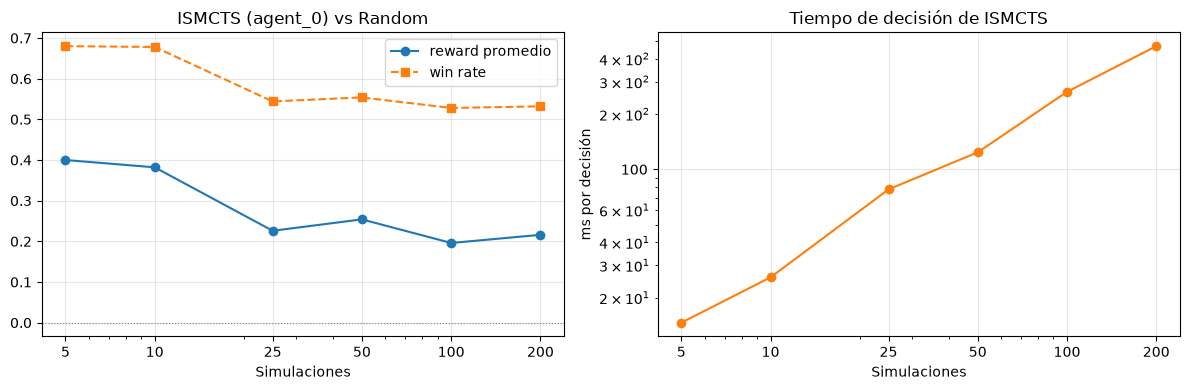

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_exp2.sims, df_exp2.avg_reward, marker='o', label='reward promedio')
axes[0].plot(df_exp2.sims, df_exp2.win_rate, marker='s', linestyle='--', label='win rate')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_xscale('log')
log_xticks(axes[0], sim_grid)
axes[0].set_xlabel('Simulaciones')
axes[0].set_title('ISMCTS (agent_0) vs Random')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_exp2.sims, df_exp2.avg_time_ms, marker='o', color='tab:orange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
log_xticks(axes[1], sim_grid)
axes[1].yaxis.set_major_formatter(PLAIN)
axes[1].set_xlabel('Simulaciones')
axes[1].set_ylabel('ms por decisión')
axes[1].set_title('Tiempo de decisión de ISMCTS')
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp2_ismcts_vs_random.png')
plt.show()

In [162]:
# Estadísticas detalladas de rewards — Exp 2
rows_detail2 = []
for sims in sim_grid:
    ism0 = InformationSetMCTS(game=game, agent='agent_0', simulations=sims,
                               rollouts=10, sample_from_infoset=kuhn_sample)
    rnd1 = RandomAgent(game=game, agent='agent_1')
    agents = {'agent_0': ism0, 'agent_1': rnd1}

    rewards, times = [], []
    for _ in range(N):
        game.reset()
        while not game.terminated():
            aid = game.agent_selection
            t0 = time.perf_counter()
            a = agents[aid].action()
            if aid == 'agent_0':
                times.append(time.perf_counter() - t0)
            game.step(a)
        rewards.append(game.reward('agent_0'))

    r = np.array(rewards)
    rows_detail2.append(dict(
        sims=sims,
        mean=round(r.mean(), 4),
        std=round(r.std(), 4),
        win_pct=round((r > 0).mean() * 100, 1),
        loss_pct=round((r < 0).mean() * 100, 1),
        avg_time_ms=round(np.mean(times) * 1000, 3),
    ))

pd.DataFrame(rows_detail2)

,sims,mean,std,win_pct,loss_pct,avg_time_ms
0,5,0.410,1.5132,68.2,31.8,14.523
1,10,0.396,1.4626,69.0,31.0,26.322
2,25,0.238,1.4119,52.8,47.2,61.583
3,50,0.240,1.3966,54.8,45.2,121.938
4,100,0.350,1.3797,58.8,41.2,235.782
5,200,0.362,1.3678,59.2,40.8,469.316


**Análisis — Exp 2:**
ISMCTS no tiene entrenamiento offline: reconstruye el árbol de búsqueda en cada decisión. \
Con pocas simulaciones (5-10) ya obtiene rewards positivos contra Random, \
pero el plateau se alcanza más gradualmente que CFR. \
El tiempo de decisión crece linealmente con las simulaciones (eje derecho del gráfico): \
más cómputo mejora el juego, pero a un costo proporcional — sin el "amortizamiento" \
que obtiene CFR al reutilizar la política entrenada en todas las partidas.

## Experimento 3 — CFR vs ISMCTS

**3a:** CFR (1000 iters, agent_0) vs ISMCTS (agent_1) con `simulations` variable.  
**3b:** ISMCTS (100 sims, agent_1) vs CFR (agent_0) con `train_iters` variable.

In [163]:
# 3a: CFR(1000) fijo vs ISMCTS variable
cfr0_ref = CounterFactualRegret(game=game, agent='agent_0')
cfr0_ref.train(1000)

rows_3a = []
for sims in [5, 10, 25, 50, 100, 200]:
    ism1 = InformationSetMCTS(game=game, agent='agent_1', simulations=sims,
                               rollouts=10, sample_from_infoset=kuhn_sample)
    agents = {'agent_0': cfr0_ref, 'agent_1': ism1}

    rewards = []
    for _ in range(N):
        game.reset()
        while not game.terminated():
            a = agents[game.agent_selection].action()
            game.step(a)
        rewards.append(game.reward('agent_0'))

    rows_3a.append(dict(sims=sims, avg_reward_cfr=np.mean(rewards)))

# 3b: ISMCTS(100) fijo vs CFR variable
ism1_ref = InformationSetMCTS(game=game, agent='agent_1', simulations=100,
                               rollouts=10, sample_from_infoset=kuhn_sample)

rows_3b = []
for iters in [100, 500, 1000, 2000]:
    cfr0 = CounterFactualRegret(game=game, agent='agent_0')
    cfr0.train(iters)

    agents = {'agent_0': cfr0, 'agent_1': ism1_ref}
    rewards = []
    for _ in range(N):
        game.reset()
        while not game.terminated():
            a = agents[game.agent_selection].action()
            game.step(a)
        rewards.append(game.reward('agent_0'))

    rows_3b.append(dict(iters=iters, avg_reward_cfr=np.mean(rewards)))

df_3a = pd.DataFrame(rows_3a)
df_3b = pd.DataFrame(rows_3b)
print(df_3a.to_string(index=False))
print()
print(df_3b.to_string(index=False))

 sims  avg_reward_cfr
    5          -0.240
   10          -0.310
   25          -0.344
   50          -0.200
  100          -0.238
  200          -0.324

 iters  avg_reward_cfr
   100          -0.482
   500          -0.312
  1000          -0.304
  2000          -0.400


Guardada: ../informe/figures/KuhnPoker/exp3_cfr_vs_ismcts.png


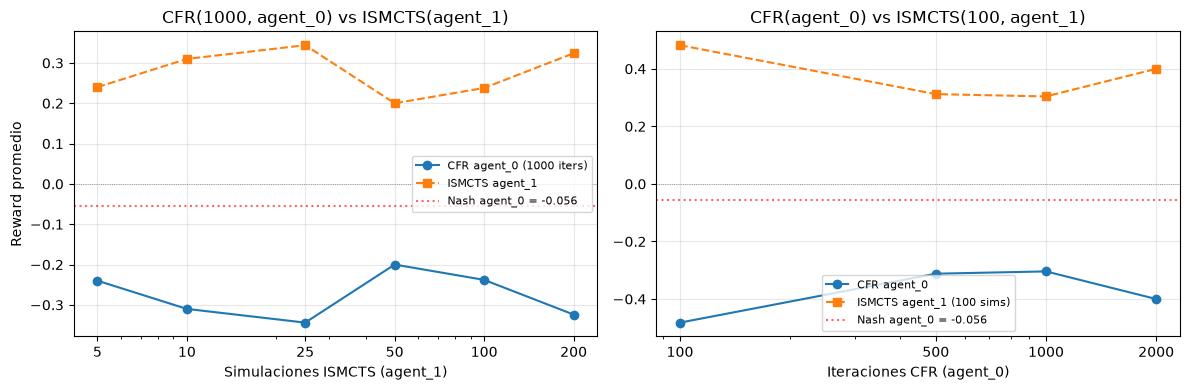

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_3a.sims, df_3a.avg_reward_cfr, marker='o', color='tab:blue', label='CFR agent_0 (1000 iters)')
axes[0].plot(df_3a.sims, -df_3a.avg_reward_cfr, marker='s', color='tab:orange', linestyle='--', label='ISMCTS agent_1')
axes[0].axhline(NASH_0, color='red', linestyle=':', alpha=0.6, label=f'Nash agent_0 = {NASH_0:.3f}')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.6)
axes[0].set_xscale('log')
log_xticks(axes[0], [5, 10, 25, 50, 100, 200])
axes[0].set_xlabel('Simulaciones ISMCTS (agent_1)')
axes[0].set_ylabel('Reward promedio')
axes[0].set_title('CFR(1000, agent_0) vs ISMCTS(agent_1)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_3b.iters, df_3b.avg_reward_cfr, marker='o', color='tab:blue', label='CFR agent_0')
axes[1].plot(df_3b.iters, -df_3b.avg_reward_cfr, marker='s', color='tab:orange', linestyle='--', label='ISMCTS agent_1 (100 sims)')
axes[1].axhline(NASH_0, color='red', linestyle=':', alpha=0.6, label=f'Nash agent_0 = {NASH_0:.3f}')
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.6)
axes[1].set_xscale('log')
log_xticks(axes[1], [100, 500, 1000, 2000])
axes[1].set_xlabel('Iteraciones CFR (agent_0)')
axes[1].set_title('CFR(agent_0) vs ISMCTS(100, agent_1)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp3_cfr_vs_ismcts.png')
plt.show()

**Análisis — Exp 3:**
El **Exp 3a** muestra cuántas simulaciones necesita ISMCTS para igualar a CFR(1000): \
en Kuhn Poker esto ocurre con pocas simulaciones porque el árbol de juego es muy pequeño. \
Cuando las simulaciones son bajas, CFR tiene ventaja clara por su convergencia al Nash eq. \
El **Exp 3b** muestra la curva inversa: CFR necesita cierta cantidad de iteraciones \
para superar a ISMCTS(100). El punto de cruce indica cuánto "cuesta" el entrenamiento \
offline para alcanzar la calidad de un ISMCTS con presupuesto moderado. \
Que el reward de CFR (agent_0) sea negativo indica que agente_1 (ISMCTS) juega mejor \
que Nash, lo que sólo es posible si agent_0 (CFR) juega peor que Nash.

## Experimento 4 — Auto-juego: convergencia al equilibrio de Nash

En auto-juego simétrico, el reward promedio de agente_0 debería converger a **−1/18 ≈ −0.056**.

Se usa  partidas (el doble que en los experimentos anteriores) para reducir la varianza de la estimación: en auto-juego ambos agentes son competitivos, las partidas son más ajustadas y el reward promedio resultante tiene más variabilidad que contra Random.

- **CFR vs CFR:** convergencia garantizada al Nash eq.
- **ISMCTS vs ISMCTS:** sin garantías teóricas en info imperfecta.

In [ ]:
N_SELF = 200
rows_cfr, rows_ism = [], []

def cfr_expected_reward(c0, game_ref):
    """Reward exacto de agent_0 recorriendo el árbol con las políticas CFR aprendidas."""
    from itertools import permutations
    shared = c0.node_dict

    def tree_ev(g):
        if g.terminated():
            return g.reward('agent_0')
        agent = g.agent_selection
        node = shared.get(g.observe(agent))
        policy = node.policy() if node else np.full(g.num_actions(agent), 0.5)
        total = 0.0
        for a in range(g.num_actions(agent)):
            ng = g.clone()
            ng.step(a)
            total += policy[a] * tree_ev(ng)
        return total

    deals = list(permutations(game_ref._cards, game_ref.num_agents))
    total = 0.0
    for deal in deals:
        g = game_ref.clone()
        g.reset()
        g._hand = np.array(deal)
        total += tree_ev(g)
    return total / len(deals)

for iters in [100, 500, 1000, 2000]:
    c0 = CounterFactualRegret(game=game, agent='agent_0')
    c1 = CounterFactualRegret(game=game, agent='agent_1')
    c1.node_dict = c0.node_dict
    train_alternated(c0, c1, total_iters=iters, block=min(100, iters))
    reward = cfr_expected_reward(c0, game)
    rows_cfr.append(dict(iters=iters, avg_reward=round(reward, 4)))

for sims in [5, 50, 200, 500]:
    i0 = InformationSetMCTS(game=game, agent='agent_0', simulations=sims,
                             rollouts=8, sample_from_infoset=kuhn_sample)
    i1 = InformationSetMCTS(game=game, agent='agent_1', simulations=sims,
                             rollouts=8, sample_from_infoset=kuhn_sample)
    agents = {'agent_0': i0, 'agent_1': i1}

    rewards = []
    for _ in range(N_SELF):
        game.reset()
        while not game.terminated():
            a = agents[game.agent_selection].action()
            game.step(a)
        rewards.append(game.reward('agent_0'))

    rows_ism.append(dict(sims=sims, avg_reward=round(np.mean(rewards), 4)))

df_cfr_self = pd.DataFrame(rows_cfr)
df_ism_self = pd.DataFrame(rows_ism)
print('CFR vs CFR (reward exacto, Nash = -0.0556):')
print(df_cfr_self.to_string(index=False))
print('\nISMCTS vs ISMCTS (N=200 partidas):')
print(df_ism_self.to_string(index=False))

CFR vs CFR (reward exacto, Nash = -0.0556):
 iters  avg_reward
   100     -0.2936
   500     -0.0742
  1000     -0.0594
  2000     -0.0469

ISMCTS vs ISMCTS (N=200 partidas):
 sims  avg_reward
    5      -0.190
   10      -0.325
   25      -0.025
   50       0.050
  100      -0.090
  200      -0.360


Guardada: ../informe/figures/KuhnPoker/exp4_selfplay.png


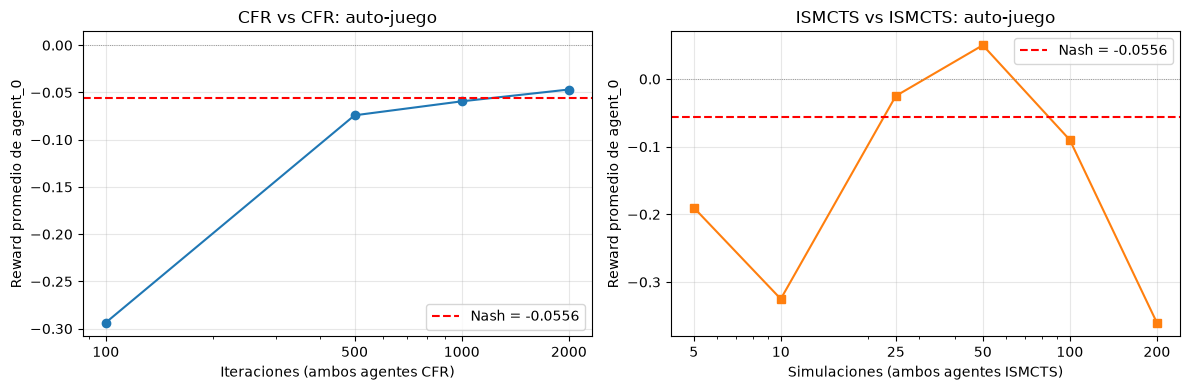

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_cfr_self.iters, df_cfr_self.avg_reward, marker='o')
axes[0].axhline(NASH_0, color='red', linestyle='--', label=f'Nash = {NASH_0:.4f}')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.6)
axes[0].set_xscale('log')
log_xticks(axes[0], [100, 500, 1000, 2000])
axes[0].set_xlabel('Iteraciones (ambos agentes CFR)')
axes[0].set_ylabel('Reward promedio de agent_0')
axes[0].set_title('CFR vs CFR: auto-juego')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_ism_self.sims, df_ism_self.avg_reward, marker='s', color='tab:orange')
axes[1].axhline(NASH_0, color='red', linestyle='--', label=f'Nash = {NASH_0:.4f}')
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.6)
axes[1].set_xscale('log')
log_xticks(axes[1], [5, 10, 25, 50, 100, 200])
axes[1].set_xlabel('Simulaciones (ambos agentes ISMCTS)')
axes[1].set_ylabel('Reward promedio de agent_0')
axes[1].set_title('ISMCTS vs ISMCTS: auto-juego')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp4_selfplay.png')
plt.show()

**Análisis — Exp 4:**
**CFR vs CFR:** con pocas iteraciones los rewards se desvían de −1/18 porque una o ambas \
políticas aún son subóptimas — el error de Nash es alto. A medida que crecen las iteraciones, \
el reward de agent_0 converge hacia −1/18, verificando empíricamente la garantía teórica de CFR. \
**ISMCTS vs ISMCTS:** sin garantía de convergencia al Nash eq en información imperfecta, \
el resultado depende de cuán bien la determinización (`random_change`) captura la incertidumbre. \
Si el reward se estabiliza cerca de −1/18, es una evidencia de que ISMCTS juega \
una estrategia cercana al Nash por construcción (el árbol pequeño lo favorece). \
Desviaciones sistemáticas indicarían que ISMCTS explota sesgos propios y no converge al equilibrio.

## Benchmark: comparación global de agentes

Se comparan todos los agentes con una misma configuración: \
cada agente juega como **agente_1** (segundo jugador) contra **Random** fijo como agente_0. \
Esto aísla la calidad del agente de la ventaja/desventaja posicional. \
El valor Nash de referencia para agente_1 es **+1/18 ≈ +0.056**.

In [167]:
N_BENCH = 500

def make_cfr_pair(iters):
    c0 = CounterFactualRegret(game=game, agent='agent_0')
    c1 = CounterFactualRegret(game=game, agent='agent_1')
    c1.node_dict = c0.node_dict
    train_alternated(c0, c1, total_iters=iters, block=min(100, iters))
    return c0, c1

cfr0_100,  cfr1_100  = make_cfr_pair(100)
cfr0_1000, cfr1_1000 = make_cfr_pair(1000)
cfr0_5000, cfr1_5000 = make_cfr_pair(5000)

configs = [
    ('Random',            RandomAgent(game=game, agent='agent_1')),
    ('CFR (100 iters)',   cfr1_100),
    ('CFR (1000 iters)',  cfr1_1000),
    ('CFR (5000 iters)',  cfr1_5000),
    ('ISMCTS (10 sims)',  InformationSetMCTS(game=game, agent='agent_1', simulations=10,  rollouts=10, sample_from_infoset=kuhn_sample)),
    ('ISMCTS (50 sims)',  InformationSetMCTS(game=game, agent='agent_1', simulations=50,  rollouts=10, sample_from_infoset=kuhn_sample)),
    ('ISMCTS (200 sims)', InformationSetMCTS(game=game, agent='agent_1', simulations=200, rollouts=10, sample_from_infoset=kuhn_sample)),
]

rnd0 = RandomAgent(game=game, agent='agent_0')
rows_bench = []
for label, agent1 in configs:
    agents = {'agent_0': rnd0, 'agent_1': agent1}

    rewards, times = [], []
    for _ in range(N_BENCH):
        game.reset()
        while not game.terminated():
            aid = game.agent_selection
            t0 = time.perf_counter()
            a = agents[aid].action()
            if aid == 'agent_1':
                times.append(time.perf_counter() - t0)
            game.step(a)
        rewards.append(game.reward('agent_1'))

    r = np.array(rewards)
    rows_bench.append(dict(
        agente=label,
        mean=round(r.mean(), 4),
        std=round(r.std(), 4),
        win_pct=round((r > 0).mean() * 100, 1),
        loss_pct=round((r < 0).mean() * 100, 1),
        avg_time_ms=round(np.mean(times) * 1000, 3),
    ))
    print(f'{label}: reward={r.mean():.4f} ± {r.std():.4f}  win={100*(r>0).mean():.1f}%  ms/dec={np.mean(times)*1000:.3f}')

df_bench = pd.DataFrame(rows_bench)
df_bench

Random: reward=-0.1160 ± 1.4624  win=44.4%  ms/dec=0.014
CFR (100 iters): reward=0.2840 ± 1.5477  win=55.8%  ms/dec=0.013
CFR (1000 iters): reward=0.1800 ± 1.4267  win=47.8%  ms/dec=0.012
CFR (5000 iters): reward=0.2480 ± 1.4207  win=49.8%  ms/dec=0.011
ISMCTS (10 sims): reward=0.3540 ± 1.4875  win=55.0%  ms/dec=23.197
ISMCTS (50 sims): reward=0.2680 ± 1.5074  win=50.6%  ms/dec=109.830
ISMCTS (200 sims): reward=0.2540 ± 1.5315  win=51.4%  ms/dec=434.155


,agente,mean,std,win_pct,loss_pct,avg_time_ms
0,Random,-0.116,1.4624,44.4,55.6,0.014
1,CFR (100 iters),0.284,1.5477,55.8,44.2,0.013
2,CFR (1000 iters),0.180,1.4267,47.8,52.2,0.012
3,CFR (5000 iters),0.248,1.4207,49.8,50.2,0.011
4,ISMCTS (10 sims),0.354,1.4875,55.0,45.0,23.197
5,ISMCTS (50 sims),0.268,1.5074,50.6,49.4,109.830
6,ISMCTS (200 sims),0.254,1.5315,51.4,48.6,434.155


Guardada: ../informe/figures/KuhnPoker/benchmark_global.png


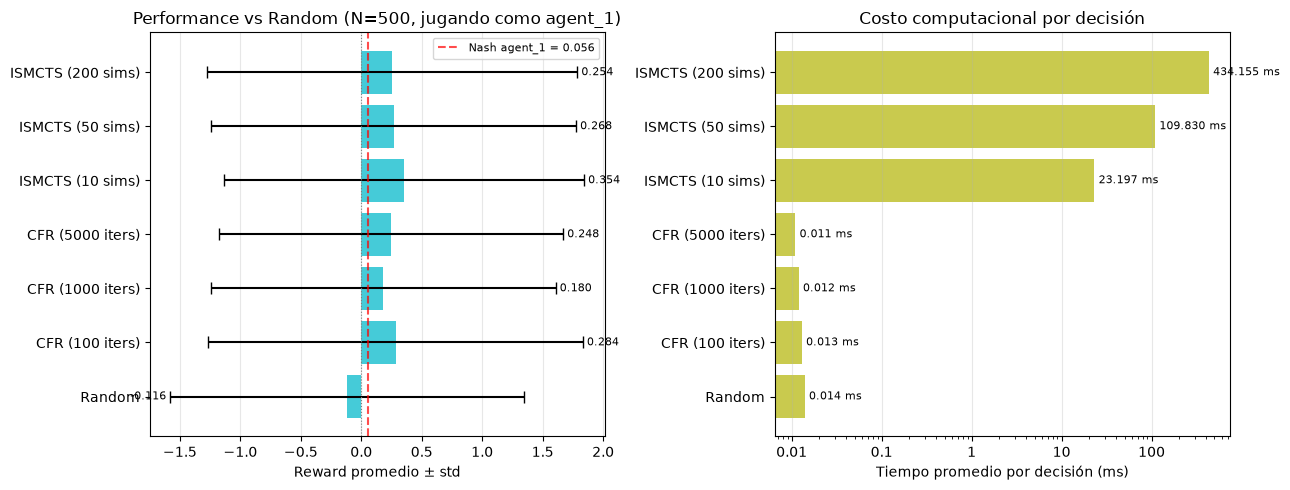

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = df_bench.agente
x = np.arange(len(labels))
width = 0.5

# Reward con barras de error (std)
bars = axes[0].barh(labels, df_bench['mean'], xerr=df_bench['std'],
                    capsize=4, color='tab:cyan', alpha=0.8)
axes[0].axvline(NASH_1, color='red', linestyle='--', alpha=0.7, label=f'Nash agent_1 = {NASH_1:.3f}')
axes[0].axvline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0].bar_label(bars, labels=[f'{v:.3f}' for v in df_bench['mean']], padding=3, fontsize=8)
axes[0].set_xlabel('Reward promedio ± std')
axes[0].set_title(f'Performance vs Random (N={N_BENCH}, jugando como agent_1)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='x')

# Tiempo de decisión
bars2 = axes[1].barh(labels, df_bench['avg_time_ms'], color='tab:olive', alpha=0.8)
axes[1].bar_label(bars2, labels=[f'{v:.3f} ms' for v in df_bench['avg_time_ms']], padding=3, fontsize=8)
axes[1].set_xlabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo computacional por decisión')
axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(PLAIN)
axes[1].xaxis.set_minor_formatter(NullFormatter())
axes[1].grid(alpha=0.3, axis='x')

fig.tight_layout()
savefig(fig, 'benchmark_global.png')
plt.show()

## Conclusiones

### Convergencia al Nash equilibrium

- **CFR** converge al Nash eq con suficientes iteraciones: las políticas aprendidas se acercan a los valores teóricos y el reward en auto-juego converge a −1/18. La tabla de la celda de entrenamiento cuantifica el error por information set.
- **ISMCTS** no tiene garantías de convergencia al Nash eq en información imperfecta. El Exp. 4 muestra si empíricamente se estabiliza cerca del valor teórico.

### Performance contra Random

Ambos agentes superan a Random incluso con presupuesto mínimo (Exp. 1 y 2). CFR es efectivo con pocas iteraciones porque el espacio de information sets de Kuhn Poker es pequeño (solo 12 nodos).

### CFR vs ISMCTS (Exp. 3)

CFR (offline) tiene tiempo de decisión O(1); ISMCTS (online) paga el costo en cada jugada. En un juego tan pequeño como Kuhn Poker, CFR bien entrenado tiende a tener ventaja por su convergencia garantizada al equilibrio.

| Aspecto | CFR | ISMCTS |
|---------|-----|--------|
| Entrenamiento | Offline (antes de jugar) | No (decide durante la partida) |
| Tiempo de decisión | O(1) — tabla de políticas | O(simulaciones) |
| Garantía Nash eq | Sí | No en info. imperfecta |
| Info. imperfecta | Nativo | Requiere determinización |